In [1]:
# ============================================================
# BLOCO 1 - UPLOAD E LEITURA DO NETCDF
# ============================================================

!pip install netCDF4 -q

import netCDF4 as nc
import pandas as pd
import numpy as np

from google.colab import files

# --------------------------------------------------
# Upload do arquivo .nc
# --------------------------------------------------

uploaded = files.upload()

arquivo = list(uploaded.keys())[0]

print(f"Arquivo carregado: {arquivo}")

# --------------------------------------------------
# Leitura do NetCDF
# --------------------------------------------------

ds = nc.Dataset(arquivo)

print(ds)

print("\n========================")
print("VARIÁVEIS DISPONÍVEIS")
print("========================")

for var in ds.variables:
    print(var)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.1 MB/s eta 0:00:00


Saving Bsantos.nc to Bsantos.nc
Arquivo carregado: Bsantos.nc
<class 'netCDF4.Dataset'>
root group (NETCDF3_64BIT_OFFSET data model, file format NETCDF3):
    description: Buoy santos
    history: Created Fri Dec  8 11:04:48 2017
    source: Moored buoy from PNBOIA
    institution: GOOS-Brasil
    comment: These data were obtained from ARGOS system and are divided into two groups, characterized by flag 1 and flag 2. Parameters from anemometer number 1 are presented in both flags
    data_management: SALT - Sea & Limno Technology
    dimensions(sizes): time(23426)
    variables(dimensions): float64 time(time), float32 latitude(time), float32 longitude(time), float32 sst(time), float32 cm_int1(time), float32 cm_int2(time), float32 cm_int3(time), float32 cm_dir1(time), float32 cm_dir2(time), float32 cm_dir3(time), float32 pressure(time), float32 temp_air(time), float32 rel_humid(time), float32 dew_point(time), float32 avg_wind_int1(time), float32 wind_gust1(time), float32 wind_dir1(time),

In [2]:
# ============================================================
# BLOCO 2 - CONVERSÃO DO NETCDF PARA DATAFRAME
# Versão robusta para datas cftime/NetCDF
# ============================================================

# Converter tempo do NetCDF para datas reais
time_var = ds.variables["time"]
datas_cftime = nc.num2date(time_var[:], units=time_var.units)

# Converter manualmente cada data para datetime do Pandas
datas = pd.to_datetime(
    [
        f"{d.year:04d}-{d.month:02d}-{d.day:02d} "
        f"{d.hour:02d}:{d.minute:02d}:{d.second:02d}"
        for d in datas_cftime
    ]
)

# Montar DataFrame apenas com as variáveis do Trabalho II
df = pd.DataFrame({
    "data": datas,
    "vento": np.array(ds.variables["avg_wind_int1"][:], dtype=float),
    "temp_ar": np.array(ds.variables["temp_air"][:], dtype=float),
    "hs": np.array(ds.variables["wave_hs"][:], dtype=float)
})

# Substituir valores clássicos de ausência/inconsistência por NaN
df = df.replace([99999, -99999, 9999, -9999], np.nan)

# Garantir ordenação temporal
df = df.sort_values("data").reset_index(drop=True)

print("Shape do DataFrame:", df.shape)

print("\nIntervalo temporal:")
print(df["data"].min(), "até", df["data"].max())

print("\nPrimeiras linhas:")
display(df.head())

print("\nResumo inicial:")
display(df.describe())

print("\nValores ausentes por variável:")
display(df.isna().sum())

Shape do DataFrame: (23426, 4)

Intervalo temporal:
2014-11-15 16:50:59 até 2017-04-06 00:22:00

Primeiras linhas:


,data,vento,temp_ar,hs
0,2014-11-15 16:50:59,0.0,NaN,NaN
1,2014-11-15 18:34:00,NaN,21.799999,1.32
2,2014-11-15 18:47:00,NaN,21.900000,1.29
3,2014-11-15 19:52:59,NaN,21.900000,1.29
4,2014-11-15 20:04:00,3.0,NaN,NaN



Resumo inicial:


,data,vento,temp_ar,hs
count,23426,7714.000000,15712.000000,15712.000000
mean,2016-02-02 21:23:36.023777024,6.279855,23.862963,2.107913
min,2014-11-15 16:50:59,0.000000,-9.700000,0.000000
25%,2015-06-28 21:16:15,4.000000,21.900000,1.330000
50%,2016-02-26 13:07:59.500000,6.000000,23.900000,1.700000
75%,2016-08-16 11:51:00,8.000000,26.100000,2.230000
max,2017-04-06 00:22:00,51.000000,41.099998,1310.699951
std,NaN,3.604414,2.697954,12.104829



Valores ausentes por variável:


,0
data,0
vento,15712
temp_ar,7714
hs,7714


In [3]:
# ============================================================
# BLOCO 3 - DIAGNÓSTICO DAS VARIÁVEIS E RECORTE PARA 2016
# ============================================================

variaveis_interesse = [
    "avg_wind_int1",
    "avg_wind_int1_f2",
    "avg_wind_int2",
    "temp_air",
    "wave_hs"
]

print("ATRIBUTOS DAS VARIÁVEIS:")
for var in variaveis_interesse:
    print("\n" + "="*50)
    print(var)
    print(ds.variables[var])
    for attr in ds.variables[var].ncattrs():
        print(f"{attr}: {ds.variables[var].getncattr(attr)}")

# DataFrame com alternativas de vento
df_diag = pd.DataFrame({
    "data": df["data"],
    "vento_f1": np.array(ds.variables["avg_wind_int1"][:], dtype=float),
    "vento_f2": np.array(ds.variables["avg_wind_int1_f2"][:], dtype=float),
    "vento_2": np.array(ds.variables["avg_wind_int2"][:], dtype=float),
    "temp_ar": np.array(ds.variables["temp_air"][:], dtype=float),
    "hs": np.array(ds.variables["wave_hs"][:], dtype=float)
})

df_diag = df_diag.replace([99999, -99999, 9999, -9999], np.nan)
df_diag = df_diag.sort_values("data").reset_index(drop=True)

# Recorte para 2016
df_2016 = df_diag[
    (df_diag["data"] >= "2016-01-01") &
    (df_diag["data"] < "2017-01-01")
].copy()

print("\nShape df_diag:", df_diag.shape)
print("Shape df_2016:", df_2016.shape)

print("\nValores válidos em 2016:")
display(df_2016.notna().sum())

print("\nValores ausentes em 2016:")
display(df_2016.isna().sum())

print("\nResumo estatístico de 2016:")
display(df_2016.describe())

print("\nPrimeiras linhas de 2016:")
display(df_2016.head())

ATRIBUTOS DAS VARIÁVEIS:

avg_wind_int1
<class 'netCDF4.Variable'>
float32 avg_wind_int1(time)
    units: m/s
    long_name: Average wind speed  - Anemometer 1
unlimited dimensions: 
current shape = (23426,)
filling on, default _FillValue of 9.969209968386869e+36 used
units: m/s
long_name: Average wind speed  - Anemometer 1

avg_wind_int1_f2
<class 'netCDF4.Variable'>
float32 avg_wind_int1_f2(time)
    units: m/s
    long_name: Average wind speed  - Anemometer 1 from flag 2 (see comment)
unlimited dimensions: 
current shape = (23426,)
filling on, default _FillValue of 9.969209968386869e+36 used
units: m/s
long_name: Average wind speed  - Anemometer 1 from flag 2 (see comment)

avg_wind_int2
<class 'netCDF4.Variable'>
float32 avg_wind_int2(time)
    units: m/s
    long_name: Average wind speed  - Anemometer 2
unlimited dimensions: 
current shape = (23426,)
filling on, default _FillValue of 9.969209968386869e+36 used
units: m/s
long_name: Average wind speed  - Anemometer 2

temp_air
<cla

,0
data,10950
vento_f1,3549
vento_f2,7401
vento_2,3549
temp_ar,7401
hs,7401



Valores ausentes em 2016:


,0
data,0
vento_f1,7401
vento_f2,3549
vento_2,7401
temp_ar,3549
hs,3549



Resumo estatístico de 2016:


,data,vento_f1,vento_f2,vento_2,temp_ar,hs
count,10950,3549.000000,7401.000000,3549.000000,7401.000000,7401.000000
mean,2016-06-25 23:37:46.319725824,5.976726,5.868626,5.745499,23.199899,2.147122
min,2016-01-01 00:53:00,0.000000,0.000000,0.000000,-9.700000,0.000000
25%,2016-03-30 12:58:00,4.000000,3.700000,3.000000,20.900000,1.310000
50%,2016-07-05 08:59:00,6.000000,5.800000,5.000000,22.700001,1.690000
75%,2016-09-24 19:27:59,8.000000,8.000000,8.000000,26.100000,2.270000
max,2016-12-31 23:01:59,50.000000,51.099998,48.000000,41.099998,1310.699951
std,NaN,3.739299,3.067480,4.017626,3.045640,15.420764



Primeiras linhas de 2016:


,data,vento_f1,vento_f2,vento_2,temp_ar,hs
9996,2016-01-01 00:53:00,NaN,6.7,NaN,26.100000,1.65
9997,2016-01-01 01:38:00,NaN,6.4,NaN,26.000000,1.86
9998,2016-01-01 02:28:00,NaN,4.8,NaN,25.900000,1.62
9999,2016-01-01 04:24:00,3.0,NaN,3.0,NaN,NaN
10000,2016-01-01 06:13:00,NaN,6.5,NaN,24.299999,1.88


In [4]:
# ============================================================
# BLOCO 4 - BASE FINAL 2016 + TESTE DE AUSÊNCIA E FAIXA FÍSICA
# ============================================================

df_qc = df_2016[["data", "vento_f2", "temp_ar", "hs"]].copy()

df_qc = df_qc.rename(columns={
    "vento_f2": "vento"
})

# Limites físicos/plausíveis definidos para o Trabalho II
limites = {
    "vento":   {"min": 0.0,  "max": 35.0, "unidade": "m/s"},
    "temp_ar": {"min": 0.0,  "max": 45.0, "unidade": "°C"},
    "hs":      {"min": 0.0,  "max": 20.0, "unidade": "m"}
}

# Criar flags
for var, lim in limites.items():
    df_qc[f"{var}_flag_ausente"] = df_qc[var].isna()
    df_qc[f"{var}_flag_faixa"] = (
        df_qc[var].notna() &
        ((df_qc[var] < lim["min"]) | (df_qc[var] > lim["max"]))
    )

# Resumo dos testes
resumo_qc = []

for var, lim in limites.items():
    n_total = len(df_qc)
    n_validos = df_qc[var].notna().sum()
    n_ausentes = df_qc[f"{var}_flag_ausente"].sum()
    n_faixa = df_qc[f"{var}_flag_faixa"].sum()

    resumo_qc.append({
        "variavel": var,
        "unidade": lim["unidade"],
        "limite_min": lim["min"],
        "limite_max": lim["max"],
        "N_total": n_total,
        "N_validos": n_validos,
        "N_ausentes": n_ausentes,
        "N_fora_faixa": n_faixa,
        "%_ausentes": 100 * n_ausentes / n_total,
        "%_fora_faixa": 100 * n_faixa / n_total
    })

resumo_qc = pd.DataFrame(resumo_qc)

print("BASE FINAL DO TRABALHO II:")
display(df_qc.head())

print("\nRESUMO QC — AUSÊNCIA E FAIXA FÍSICA:")
display(resumo_qc)

print("\nREGISTROS FORA DA FAIXA FÍSICA:")
for var in limites.keys():
    print("\n" + "="*60)
    print(var)
    display(df_qc.loc[df_qc[f"{var}_flag_faixa"], ["data", var]])

BASE FINAL DO TRABALHO II:


,data,vento,temp_ar,hs,vento_flag_ausente,vento_flag_faixa,temp_ar_flag_ausente,temp_ar_flag_faixa,hs_flag_ausente,hs_flag_faixa
9996,2016-01-01 00:53:00,6.7,26.100000,1.65,False,False,False,False,False,False
9997,2016-01-01 01:38:00,6.4,26.000000,1.86,False,False,False,False,False,False
9998,2016-01-01 02:28:00,4.8,25.900000,1.62,False,False,False,False,False,False
9999,2016-01-01 04:24:00,NaN,NaN,NaN,True,False,True,False,True,False
10000,2016-01-01 06:13:00,6.5,24.299999,1.88,False,False,False,False,False,False



RESUMO QC — AUSÊNCIA E FAIXA FÍSICA:


,variavel,unidade,limite_min,limite_max,N_total,N_validos,N_ausentes,N_fora_faixa,%_ausentes,%_fora_faixa
0,vento,m/s,0.0,35.0,10950,7401,3549,2,32.410959,0.018265
1,temp_ar,°C,0.0,45.0,10950,7401,3549,2,32.410959,0.018265
2,hs,m,0.0,20.0,10950,7401,3549,14,32.410959,0.127854



REGISTROS FORA DA FAIXA FÍSICA:

vento


,data,vento
17325,2016-08-16 11:51:00,51.099998
18267,2016-09-27 05:17:00,46.000000



temp_ar


,data,temp_ar
17605,2016-08-16 11:51:00,-9.7
19062,2016-10-26 10:05:59,-2.7



hs


,data,hs
10473,2016-01-15 16:01:00,98.739998
10474,2016-01-15 16:01:00,98.739998
10536,2016-01-17 13:58:00,20.469999
12630,2016-03-27 17:35:59,20.469999
12631,2016-03-27 17:35:59,20.469999
12651,2016-03-27 17:35:59,20.469999
12652,2016-03-27 17:35:59,20.469999
12653,2016-03-27 17:35:59,20.469999
12654,2016-03-27 17:35:59,20.469999
13152,2016-03-30 12:58:00,20.469999


In [5]:
# ============================================================
# BLOCO 5 - FLAG CONSOLIDADA DO TESTE QC1
# ============================================================

for var in ["vento", "temp_ar", "hs"]:

    df_qc[f"{var}_qc1"] = (
        df_qc[f"{var}_flag_ausente"] |
        df_qc[f"{var}_flag_faixa"]
    )

print("Resumo QC1:")

for var in ["vento", "temp_ar", "hs"]:

    total_flagados = df_qc[f"{var}_qc1"].sum()

    print(
        f"{var}: {total_flagados} registros sinalizados"
    )

Resumo QC1:
vento: 3551 registros sinalizados
temp_ar: 3551 registros sinalizados
hs: 3563 registros sinalizados


In [6]:
# ============================================================
# BLOCO 6 - QC2: TESTE DE SPIKE / TAXA DE VARIAÇÃO
# ============================================================

# Limiares escolhidos para variação entre registros consecutivos
limiares_spike = {
    "vento": 10.0,     # m/s
    "temp_ar": 5.0,    # °C
    "hs": 3.0          # m
}

for var, limiar in limiares_spike.items():

    # diferença absoluta entre medições consecutivas
    df_qc[f"{var}_delta"] = df_qc[var].diff().abs()

    # flag de spike
    df_qc[f"{var}_flag_spike"] = df_qc[f"{var}_delta"] > limiar

    # flag consolidada QC1 + QC2
    df_qc[f"{var}_qc_total"] = (
        df_qc[f"{var}_qc1"] |
        df_qc[f"{var}_flag_spike"]
    )

# Resumo do QC2
resumo_qc2 = []

for var, limiar in limiares_spike.items():

    resumo_qc2.append({
        "variavel": var,
        "limiar_spike": limiar,
        "N_spikes": int(df_qc[f"{var}_flag_spike"].sum()),
        "%_spikes": 100 * df_qc[f"{var}_flag_spike"].sum() / len(df_qc)
    })

resumo_qc2 = pd.DataFrame(resumo_qc2)

print("RESUMO QC2 — SPIKE / TAXA DE VARIAÇÃO:")
display(resumo_qc2)

print("\nREGISTROS SINALIZADOS COMO SPIKE:")

for var in ["vento", "temp_ar", "hs"]:
    print("\n" + "="*60)
    print(var)

    cols = ["data", var, f"{var}_delta", f"{var}_flag_spike"]
    display(df_qc.loc[df_qc[f"{var}_flag_spike"], cols].head(20))

RESUMO QC2 — SPIKE / TAXA DE VARIAÇÃO:


,variavel,limiar_spike,N_spikes,%_spikes
0,vento,10.0,34,0.310502
1,temp_ar,5.0,215,1.963470
2,hs,3.0,156,1.424658



REGISTROS SINALIZADOS COMO SPIKE:

vento


,data,vento,vento_delta,vento_flag_spike
12937,2016-03-30 12:58:00,23.200001,20.900001,True
12938,2016-03-30 12:58:00,4.800000,18.400001,True
13848,2016-03-30 12:58:00,1.100000,10.100000,True
13849,2016-03-30 12:58:00,11.200000,10.100000,True
13850,2016-03-30 12:58:00,1.100000,10.100000,True
13854,2016-03-30 12:58:00,11.600000,10.500000,True
13855,2016-03-30 12:58:00,1.100000,10.500000,True
13882,2016-03-30 12:58:00,11.800000,10.800000,True
13884,2016-03-30 12:58:00,1.200000,10.700000,True
13923,2016-03-30 12:58:00,11.300000,10.300000,True



temp_ar


,data,temp_ar,temp_ar_delta,temp_ar_flag_spike
10800,2016-01-26 10:54:00,36.900002,10.200001,True
10801,2016-01-26 11:43:00,26.900000,10.000002,True
11143,2016-02-07 05:56:00,26.700001,6.300001,True
11896,2016-03-03 09:53:59,7.000000,19.100000,True
12714,2016-03-30 12:58:00,19.200001,7.000000,True
12740,2016-03-30 12:58:00,27.299999,5.799999,True
12745,2016-03-30 12:58:00,27.799999,7.599998,True
12748,2016-03-30 12:58:00,27.799999,7.000000,True
12758,2016-03-30 12:58:00,19.200001,9.599998,True
12761,2016-03-30 12:58:00,22.000000,5.100000,True



hs


,data,hs,hs_delta,hs_flag_spike
10111,2016-01-05 05:28:00,2.720000,13.749999,True
10412,2016-01-13 21:27:00,0.740000,13.880000,True
10473,2016-01-15 16:01:00,98.739998,96.169998,True
10537,2016-01-17 17:18:59,2.030000,18.439999,True
10590,2016-01-19 09:28:59,4.600000,3.340000,True
10591,2016-01-19 10:07:00,1.260000,3.340000,True
10609,2016-01-20 01:46:00,19.459999,17.889999,True
10610,2016-01-20 04:10:00,1.790000,17.669999,True
10759,2016-01-25 01:38:59,1.160000,17.049999,True
10818,2016-01-27 00:56:59,9.180000,7.740000,True


In [7]:
# ============================================================
# BLOCO 7 - DIAGNÓSTICO DE TIMESTAMPS DUPLICADOS
# ============================================================

duplicados = df_qc[df_qc.duplicated(subset="data", keep=False)]

print("Quantidade de registros com timestamp duplicado:")
print(len(duplicados))

print("\nQuantidade de datas repetidas:")
print(duplicados["data"].nunique())

print("\nPrimeiros exemplos:")
display(
    duplicados
    .sort_values("data")
    .head(30)
)

# resumo por data

resumo_dup = (
    duplicados
    .groupby("data")
    .size()
    .reset_index(name="n_registros")
    .sort_values("n_registros", ascending=False)
)

print("\nDatas com mais registros duplicados:")
display(resumo_dup.head(20))

Quantidade de registros com timestamp duplicado:
6015

Quantidade de datas repetidas:
1711

Primeiros exemplos:


,data,vento,temp_ar,hs,vento_flag_ausente,vento_flag_faixa,temp_ar_flag_ausente,temp_ar_flag_faixa,hs_flag_ausente,hs_flag_faixa,...,hs_qc1,vento_delta,vento_flag_spike,vento_qc_total,temp_ar_delta,temp_ar_flag_spike,temp_ar_qc_total,hs_delta,hs_flag_spike,hs_qc_total
10000,2016-01-01 06:13:00,6.5,24.299999,1.88,False,False,False,False,False,False,...,False,NaN,False,False,NaN,False,False,NaN,False,False
10001,2016-01-01 06:13:00,NaN,NaN,NaN,True,False,True,False,True,False,...,True,NaN,False,True,NaN,False,True,NaN,False,True
10006,2016-01-01 09:34:00,5.2,25.700001,2.31,False,False,False,False,False,False,...,False,NaN,False,False,NaN,False,False,NaN,False,False
10007,2016-01-01 09:34:00,NaN,NaN,NaN,True,False,True,False,True,False,...,True,NaN,False,True,NaN,False,True,NaN,False,True
10008,2016-01-01 09:34:00,NaN,NaN,NaN,True,False,True,False,True,False,...,True,NaN,False,True,NaN,False,True,NaN,False,True
10012,2016-01-01 12:51:59,5.8,25.299999,2.62,False,False,False,False,False,False,...,False,0.800000,False,False,0.300001,False,False,0.37,False,False
10013,2016-01-01 12:51:59,NaN,NaN,NaN,True,False,True,False,True,False,...,True,NaN,False,True,NaN,False,True,NaN,False,True
10021,2016-01-01 22:04:59,11.1,25.200001,2.13,False,False,False,False,False,False,...,False,0.000000,False,False,0.000000,False,False,0.00,False,False
10022,2016-01-01 22:04:59,NaN,NaN,NaN,True,False,True,False,True,False,...,True,NaN,False,True,NaN,False,True,NaN,False,True
10023,2016-01-01 22:19:59,NaN,NaN,NaN,True,False,True,False,True,False,...,True,NaN,False,True,NaN,False,True,NaN,False,True



Datas com mais registros duplicados:


,data,n_registros
436,2016-03-30 12:58:00,1509
1087,2016-08-16 11:51:00,508
428,2016-03-27 17:35:59,25
76,2016-01-13 21:27:00,8
29,2016-01-06 19:27:00,8
755,2016-07-16 05:43:59,7
871,2016-07-27 12:42:59,7
1709,2016-12-31 21:58:00,7
30,2016-01-06 21:06:59,6
977,2016-08-05 09:44:00,6


In [8]:
# ============================================================
# BLOCO 8 - QC3 (FLAT LINE)
# ============================================================

flatline_limite = {
    "vento": 5,
    "temp_ar": 5,
    "hs": 5
}

for var in ["vento", "temp_ar", "hs"]:

    flag = []

    valores = df_qc[var].values

    contador = 1

    flag.append(False)

    for i in range(1, len(valores)):

        atual = valores[i]
        anterior = valores[i-1]

        if pd.isna(atual) or pd.isna(anterior):
            contador = 1
            flag.append(False)

        elif atual == anterior:
            contador += 1
            flag.append(contador >= flatline_limite[var])

        else:
            contador = 1
            flag.append(False)

    df_qc[f"{var}_flag_flatline"] = flag

In [9]:
# ============================================================
# BLOCO 9 - RESUMO QC3
# ============================================================

resumo_qc3 = []

for var in ["vento", "temp_ar", "hs"]:

    n_flat = df_qc[f"{var}_flag_flatline"].sum()

    resumo_qc3.append({
        "variavel": var,
        "limite_repeticao": flatline_limite[var],
        "N_flatline": n_flat,
        "%_flatline": 100*n_flat/len(df_qc)
    })

resumo_qc3 = pd.DataFrame(resumo_qc3)

print("RESUMO QC3 — FLAT LINE")
display(resumo_qc3)

RESUMO QC3 — FLAT LINE


,variavel,limite_repeticao,N_flatline,%_flatline
0,vento,5,41,0.374429
1,temp_ar,5,89,0.812785
2,hs,5,98,0.894977


In [10]:
# ============================================================
# BLOCO 10 - RESUMO CONSOLIDADO DOS TESTES QC
# ============================================================

resumo_consolidado = []

for var in ["vento", "temp_ar", "hs"]:

    resumo_consolidado.append({
        "variavel": var,
        "N_total": len(df_qc),
        "N_ausentes": df_qc[f"{var}_flag_ausente"].sum(),
        "N_fora_faixa": df_qc[f"{var}_flag_faixa"].sum(),
        "N_spikes": df_qc[f"{var}_flag_spike"].sum(),
        "N_flatline": df_qc[f"{var}_flag_flatline"].sum(),
        "N_QC_total": (
            df_qc[f"{var}_flag_ausente"] |
            df_qc[f"{var}_flag_faixa"] |
            df_qc[f"{var}_flag_spike"] |
            df_qc[f"{var}_flag_flatline"]
        ).sum(),
        "%_QC_total": 100 * (
            df_qc[f"{var}_flag_ausente"] |
            df_qc[f"{var}_flag_faixa"] |
            df_qc[f"{var}_flag_spike"] |
            df_qc[f"{var}_flag_flatline"]
        ).sum() / len(df_qc)
    })

resumo_consolidado = pd.DataFrame(resumo_consolidado)

print("RESUMO CONSOLIDADO DOS TESTES DE CONTROLE DE QUALIDADE")
display(resumo_consolidado)

RESUMO CONSOLIDADO DOS TESTES DE CONTROLE DE QUALIDADE


,variavel,N_total,N_ausentes,N_fora_faixa,N_spikes,N_flatline,N_QC_total,%_QC_total
0,vento,10950,3549,2,34,41,3624,33.095890
1,temp_ar,10950,3549,2,215,89,3853,35.187215
2,hs,10950,3549,14,156,98,3813,34.821918


In [11]:
# ============================================================
# BLOCO 11 - RESUMO DOS TESTES SEM CONTAR AUSÊNCIA
# ============================================================

resumo_sem_ausencia = []

for var in ["vento", "temp_ar", "hs"]:

    flag_sem_ausencia = (
        df_qc[f"{var}_flag_faixa"] |
        df_qc[f"{var}_flag_spike"] |
        df_qc[f"{var}_flag_flatline"]
    )

    n_validos = df_qc[var].notna().sum()
    n_sinalizados_sem_ausencia = flag_sem_ausencia.sum()

    resumo_sem_ausencia.append({
        "variavel": var,
        "N_validos": n_validos,
        "N_fora_faixa": df_qc[f"{var}_flag_faixa"].sum(),
        "N_spikes": df_qc[f"{var}_flag_spike"].sum(),
        "N_flatline": df_qc[f"{var}_flag_flatline"].sum(),
        "N_sinalizados_sem_ausencia": n_sinalizados_sem_ausencia,
        "%_sinalizados_sobre_validos": 100 * n_sinalizados_sem_ausencia / n_validos
    })

resumo_sem_ausencia = pd.DataFrame(resumo_sem_ausencia)

print("RESUMO DOS TESTES DE QC SEM CONTAR AUSÊNCIA")
display(resumo_sem_ausencia)

RESUMO DOS TESTES DE QC SEM CONTAR AUSÊNCIA


,variavel,N_validos,N_fora_faixa,N_spikes,N_flatline,N_sinalizados_sem_ausencia,%_sinalizados_sobre_validos
0,vento,7401,2,34,41,75,1.013377
1,temp_ar,7401,2,215,89,304,4.107553
2,hs,7401,14,156,98,264,3.567086


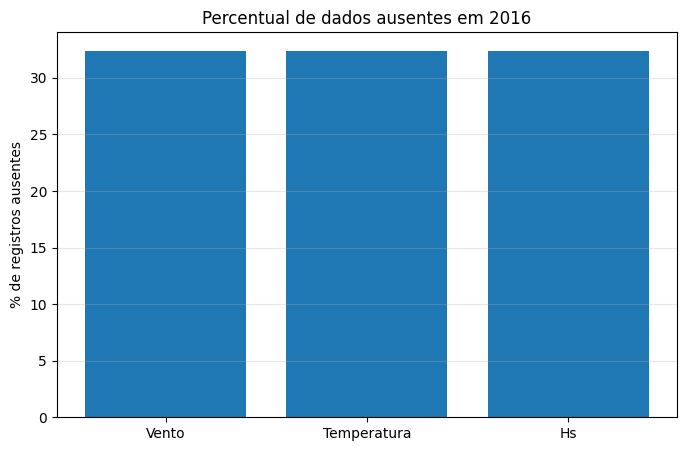

In [12]:
# ============================================================
# BLOCO 12 - GRÁFICO DE AUSÊNCIAS
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(
    ["Vento", "Temperatura", "Hs"],
    [32.41, 32.41, 32.41]
)

ax.set_ylabel("% de registros ausentes")
ax.set_title("Percentual de dados ausentes em 2016")

plt.grid(True, axis="y", alpha=0.3)

plt.show()

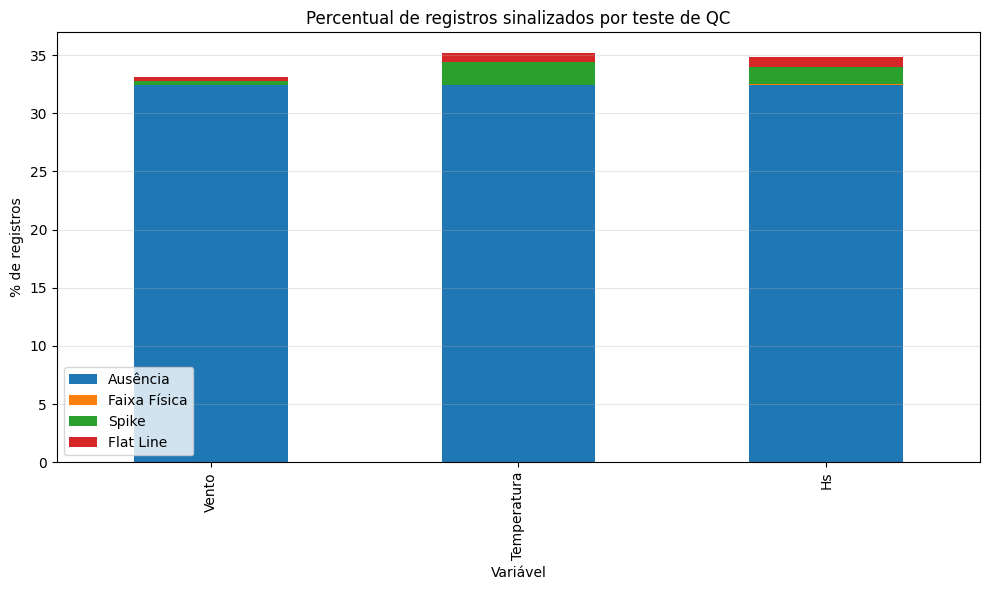

In [13]:
# ============================================================
# BLOCO 13 - GRÁFICO CONSOLIDADO DOS TESTES QC
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

qc_plot = pd.DataFrame({
    "Variável": ["Vento", "Temperatura", "Hs"],
    "Ausência": [32.410959, 32.410959, 32.410959],
    "Faixa Física": [0.018265, 0.018265, 0.127854],
    "Spike": [0.310502, 1.963470, 1.424658],
    "Flat Line": [0.374429, 0.812785, 0.894977]
})

qc_plot.set_index("Variável").plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("% de registros")
plt.title("Percentual de registros sinalizados por teste de QC")
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

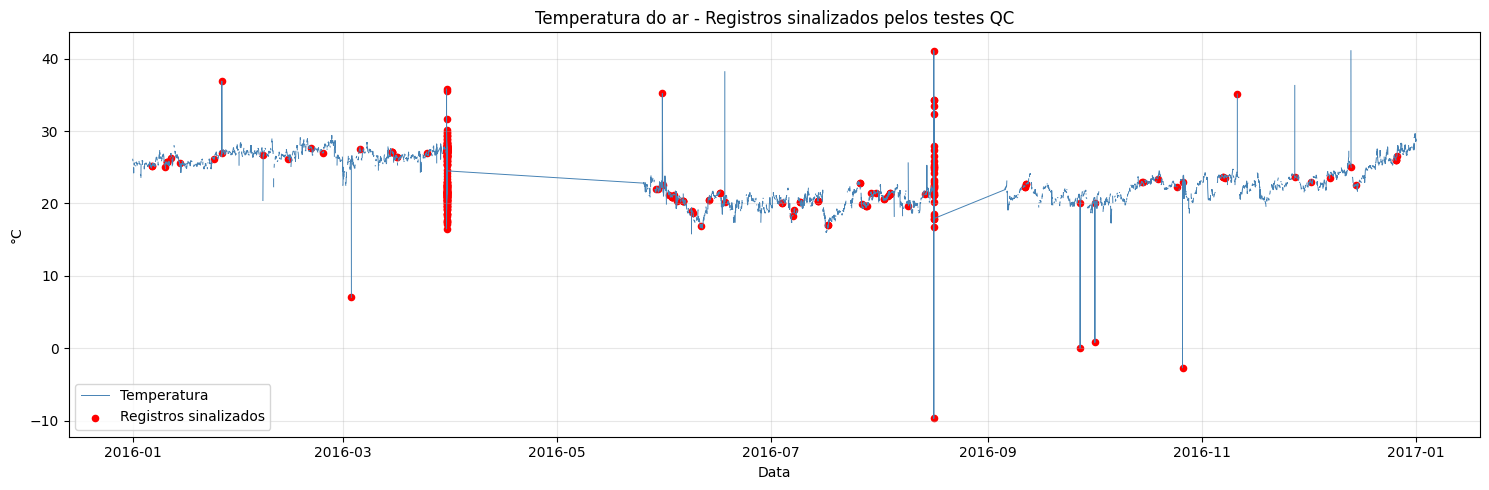

In [14]:
# ============================================================
# BLOCO 14 - SÉRIE TEMPORAL DA TEMPERATURA COM FLAGS QC
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    df_qc["data"],
    df_qc["temp_ar"],
    color="steelblue",
    linewidth=0.7,
    label="Temperatura"
)

dados_flag = df_qc[
    df_qc["temp_ar_flag_spike"] |
    df_qc["temp_ar_flag_flatline"] |
    df_qc["temp_ar_flag_faixa"]
]

plt.scatter(
    dados_flag["data"],
    dados_flag["temp_ar"],
    color="red",
    s=20,
    label="Registros sinalizados"
)

plt.title("Temperatura do ar - Registros sinalizados pelos testes QC")
plt.ylabel("°C")
plt.xlabel("Data")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

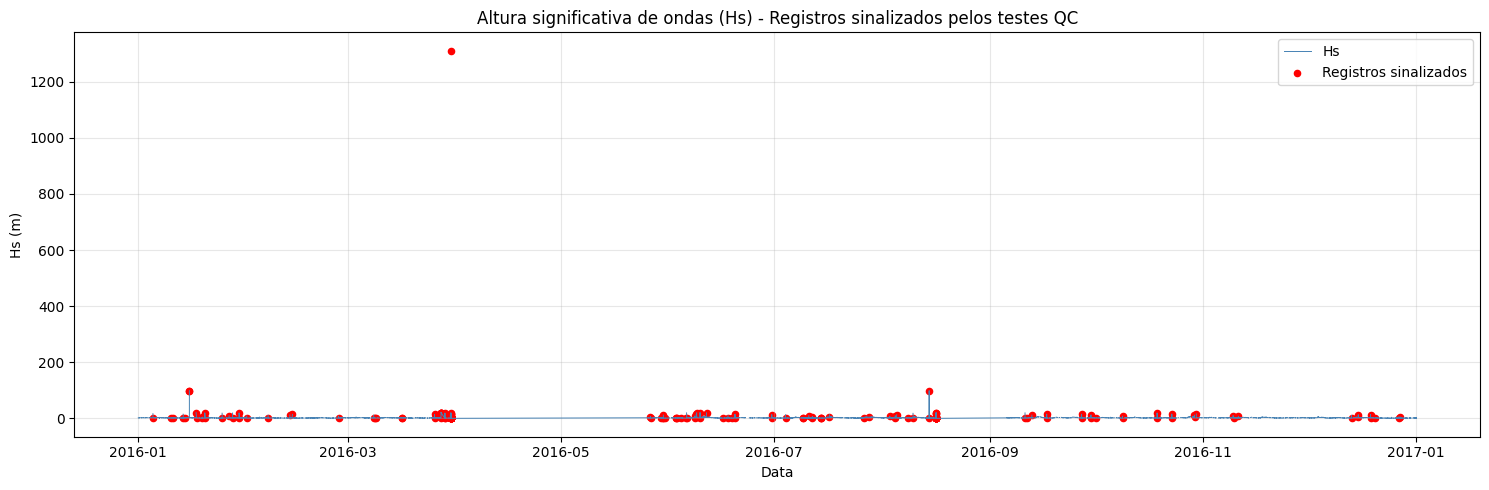

In [15]:
# ============================================================
# BLOCO 15 - SÉRIE TEMPORAL DE HS COM FLAGS QC
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    df_qc["data"],
    df_qc["hs"],
    color="steelblue",
    linewidth=0.7,
    label="Hs"
)

dados_flag = df_qc[
    df_qc["hs_flag_spike"] |
    df_qc["hs_flag_flatline"] |
    df_qc["hs_flag_faixa"]
]

plt.scatter(
    dados_flag["data"],
    dados_flag["hs"],
    color="red",
    s=20,
    label="Registros sinalizados"
)

plt.title("Altura significativa de ondas (Hs) - Registros sinalizados pelos testes QC")
plt.ylabel("Hs (m)")
plt.xlabel("Data")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

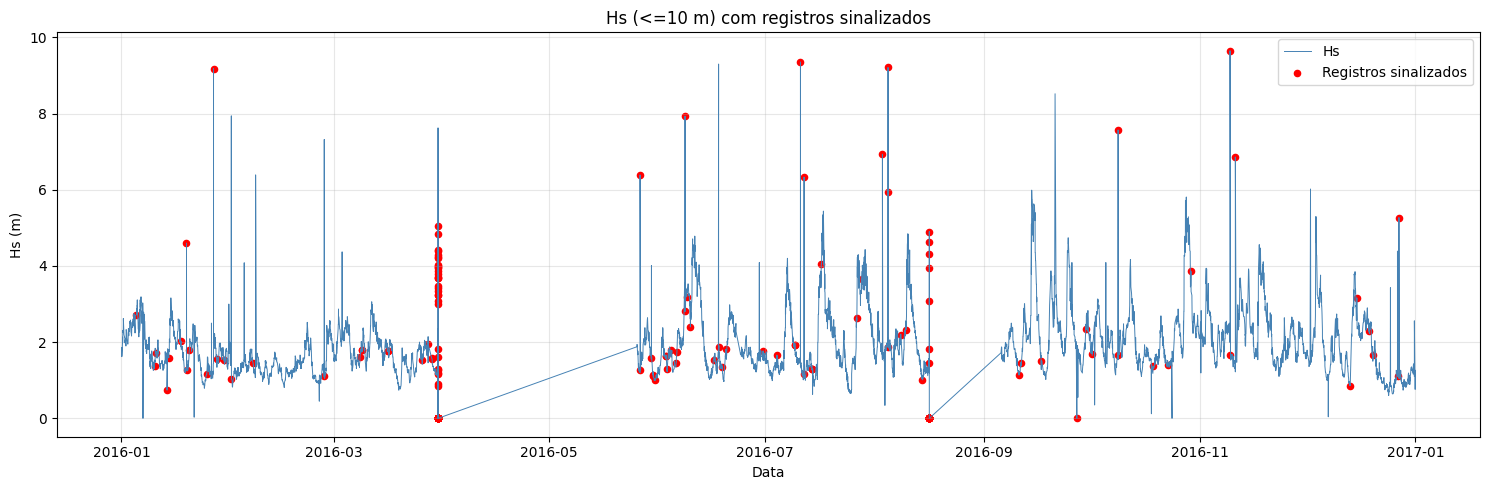

In [16]:
# ============================================================
# BLOCO 16 - Hs SEM OUTLIERS GIGANTES
# ============================================================

import matplotlib.pyplot as plt

df_hs_plot = df_qc[df_qc["hs"] <= 10].copy()

plt.figure(figsize=(15,5))

plt.plot(
    df_hs_plot["data"],
    df_hs_plot["hs"],
    color="steelblue",
    linewidth=0.7,
    label="Hs"
)

dados_flag = df_hs_plot[
    df_hs_plot["hs_flag_spike"] |
    df_hs_plot["hs_flag_flatline"] |
    df_hs_plot["hs_flag_faixa"]
]

plt.scatter(
    dados_flag["data"],
    dados_flag["hs"],
    color="red",
    s=20,
    label="Registros sinalizados"
)

plt.title("Hs (<=10 m) com registros sinalizados")
plt.ylabel("Hs (m)")
plt.xlabel("Data")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# BLOCO 17 - RESUMO DE DUPLICIDADES TEMPORAIS
# ============================================================

duplicados = (
    df_qc.groupby("data")
    .size()
    .reset_index(name="n_registros")
)

duplicados = duplicados[
    duplicados["n_registros"] > 1
].sort_values(
    "n_registros",
    ascending=False
)

print("Quantidade de timestamps duplicados:")
print(len(duplicados))

print("\nTotal de registros envolvidos:")
print(duplicados["n_registros"].sum())

print("\n10 maiores duplicidades:")
display(duplicados.head(10))

percentual_afetado = (
    duplicados["n_registros"].sum()
    / len(df_qc)
    * 100
)

print(
    f"\nPercentual de registros envolvidos em duplicidades: "
    f"{percentual_afetado:.2f}%"
)

Quantidade de timestamps duplicados:
1711

Total de registros envolvidos:
6015

10 maiores duplicidades:


,data,n_registros
2135,2016-03-30 12:58:00,1509
4165,2016-08-16 11:51:00,508
2089,2016-03-27 17:35:59,25
312,2016-01-13 21:27:00,8
129,2016-01-06 19:27:00,8
3387,2016-07-16 05:43:59,7
3649,2016-07-27 12:42:59,7
6644,2016-12-31 21:58:00,7
130,2016-01-06 21:06:59,6
3887,2016-08-05 09:44:00,6



Percentual de registros envolvidos em duplicidades: 54.93%


In [18]:
# ============================================================
# BLOCO 18 - INSPEÇÃO DO MAIOR TIMESTAMP DUPLICADO
# ============================================================

timestamp_problema = pd.Timestamp("2016-03-30 12:58:00")

caso = df_qc[df_qc["data"] == timestamp_problema]

print("Quantidade de registros:")
print(len(caso))

print("\nPrimeiras 30 linhas:")
display(caso.head(30))

print("\nResumo estatístico:")
display(caso.describe(include="all"))

Quantidade de registros:
1509

Primeiras 30 linhas:


,data,vento,temp_ar,hs,vento_flag_ausente,vento_flag_faixa,temp_ar_flag_ausente,temp_ar_flag_faixa,hs_flag_ausente,hs_flag_faixa,...,vento_qc_total,temp_ar_delta,temp_ar_flag_spike,temp_ar_qc_total,hs_delta,hs_flag_spike,hs_qc_total,vento_flag_flatline,temp_ar_flag_flatline,hs_flag_flatline
12710,2016-03-30 12:58:00,5.0,27.200001,2.36,False,False,False,False,False,False,...,False,NaN,False,False,NaN,False,False,False,False,False
12711,2016-03-30 12:58:00,9.9,27.400000,1.66,False,False,False,False,False,False,...,False,0.199999,False,False,0.70,False,False,False,False,False
12712,2016-03-30 12:58:00,5.3,24.799999,1.59,False,False,False,False,False,False,...,False,2.600000,False,False,0.07,False,False,False,False,False
12713,2016-03-30 12:58:00,3.2,26.200001,0.77,False,False,False,False,False,False,...,False,1.400002,False,False,0.82,False,False,False,False,False
12714,2016-03-30 12:58:00,4.5,19.200001,0.00,False,False,False,False,False,False,...,False,7.000000,True,True,0.77,False,False,False,False,False
12715,2016-03-30 12:58:00,4.5,22.100000,0.00,False,False,False,False,False,False,...,False,2.900000,False,False,0.00,False,False,False,False,False
12716,2016-03-30 12:58:00,5.3,23.000000,1.22,False,False,False,False,False,False,...,False,0.900000,False,False,1.22,False,False,False,False,False
12717,2016-03-30 12:58:00,6.2,26.900000,1.04,False,False,False,False,False,False,...,False,3.900000,False,False,0.18,False,False,False,False,False
12718,2016-03-30 12:58:00,4.5,23.400000,1.16,False,False,False,False,False,False,...,False,3.500000,False,False,0.12,False,False,False,False,False
12719,2016-03-30 12:58:00,5.0,23.200001,2.19,False,False,False,False,False,False,...,False,0.199999,False,False,1.03,False,False,False,False,False



Resumo estatístico:


,data,vento,temp_ar,hs,vento_flag_ausente,vento_flag_faixa,temp_ar_flag_ausente,temp_ar_flag_faixa,hs_flag_ausente,hs_flag_faixa,...,vento_qc_total,temp_ar_delta,temp_ar_flag_spike,temp_ar_qc_total,hs_delta,hs_flag_spike,hs_qc_total,vento_flag_flatline,temp_ar_flag_flatline,hs_flag_flatline
count,1509,982.000000,982.000000,982.000000,1509,1509,1509,1509,1509,1509,...,1509,786.000000,1509,1509,786.000000,1509,1509,1509,1509,1509
unique,NaN,NaN,NaN,NaN,2,1,2,1,2,2,...,2,NaN,2,2,NaN,2,2,2,1,2
top,NaN,NaN,NaN,NaN,False,False,False,False,False,False,...,False,NaN,False,False,NaN,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,982,1509,982,1509,982,1507,...,966,NaN,1341,814,NaN,1452,923,1502,1509,1459
mean,2016-03-30 12:58:00,4.102648,24.489892,2.600193,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.100382,NaN,NaN,1.312723,NaN,NaN,NaN,NaN,NaN
min,2016-03-30 12:58:00,0.000000,16.500000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,2016-03-30 12:58:00,1.500000,22.425000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.025000,NaN,NaN,0.092500,NaN,NaN,NaN,NaN,NaN
50%,2016-03-30 12:58:00,3.700000,24.100000,1.250000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.850000,NaN,NaN,1.080000,NaN,NaN,NaN,NaN,NaN
75%,2016-03-30 12:58:00,5.700000,26.900000,1.890000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4.700001,NaN,NaN,1.880000,NaN,NaN,NaN,NaN,NaN
max,2016-03-30 12:58:00,31.100000,35.799999,1310.699951,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,14.200001,NaN,NaN,18.849999,NaN,NaN,NaN,NaN,NaN


In [19]:
# ============================================================
# BLOCO 19 - QC4: TESTE DE TIMESTAMP DUPLICADO
# ============================================================

df_qc["flag_timestamp_duplicado"] = df_qc.duplicated(subset=["data"], keep=False)

n_reg_dup = df_qc["flag_timestamp_duplicado"].sum()
n_datas_dup = df_qc.loc[df_qc["flag_timestamp_duplicado"], "data"].nunique()
perc_reg_dup = 100 * n_reg_dup / len(df_qc)

print("QC4 — TIMESTAMP DUPLICADO")
print(f"Quantidade de timestamps duplicados: {n_datas_dup}")
print(f"Total de registros envolvidos: {n_reg_dup}")
print(f"Percentual de registros envolvidos: {perc_reg_dup:.2f}%")

top_duplicados = (
    df_qc[df_qc["flag_timestamp_duplicado"]]
    .groupby("data")
    .size()
    .reset_index(name="n_registros")
    .sort_values("n_registros", ascending=False)
    .head(15)
)

print("\n15 maiores duplicidades:")
display(top_duplicados)

QC4 — TIMESTAMP DUPLICADO
Quantidade de timestamps duplicados: 1711
Total de registros envolvidos: 6015
Percentual de registros envolvidos: 54.93%

15 maiores duplicidades:


,data,n_registros
436,2016-03-30 12:58:00,1509
1087,2016-08-16 11:51:00,508
428,2016-03-27 17:35:59,25
76,2016-01-13 21:27:00,8
29,2016-01-06 19:27:00,8
755,2016-07-16 05:43:59,7
871,2016-07-27 12:42:59,7
1709,2016-12-31 21:58:00,7
30,2016-01-06 21:06:59,6
977,2016-08-05 09:44:00,6


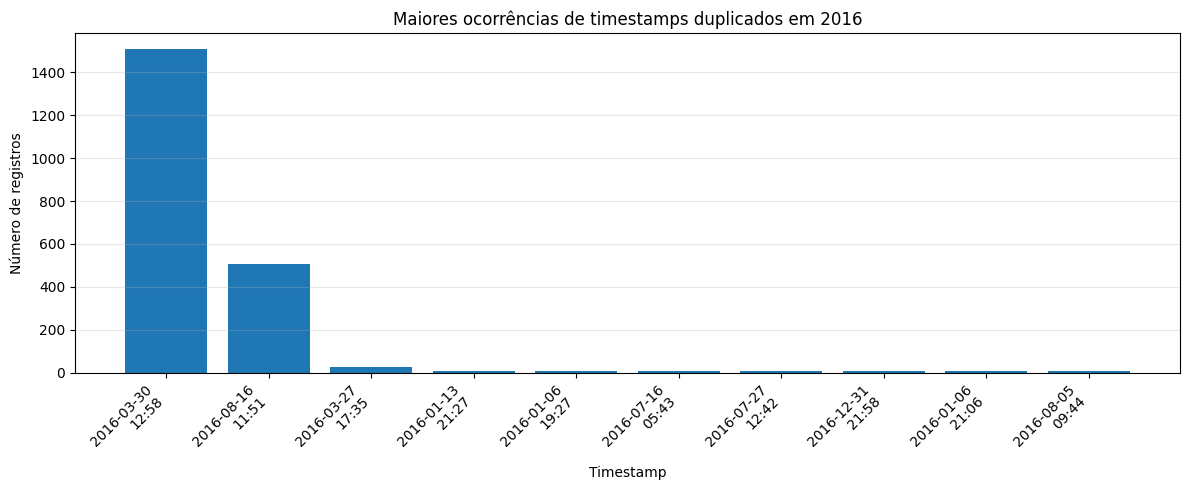

In [20]:
# ============================================================
# BLOCO 20 - GRÁFICO DO QC4: MAIORES TIMESTAMPS DUPLICADOS
# ============================================================

import matplotlib.pyplot as plt

top_plot = top_duplicados.head(10).copy()
top_plot["data_str"] = top_plot["data"].dt.strftime("%Y-%m-%d\n%H:%M")

plt.figure(figsize=(12, 5))
plt.bar(top_plot["data_str"], top_plot["n_registros"])
plt.title("Maiores ocorrências de timestamps duplicados em 2016")
plt.xlabel("Timestamp")
plt.ylabel("Número de registros")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("qc4_timestamps_duplicados.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# ============================================================
# BLOCO 21 - ESTATÍSTICAS DESCRITIVAS
# ============================================================

estatisticas = []

for var in ["vento", "temp_ar", "hs"]:

    serie = df_qc[var].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    estatisticas.append({
        "variavel": var,
        "N": len(serie),
        "media": serie.mean(),
        "mediana": serie.median(),
        "desvio_padrao": serie.std(),
        "min": serie.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "max": serie.max()
    })

estatisticas = pd.DataFrame(estatisticas)

print("ESTATÍSTICAS DESCRITIVAS")
display(estatisticas)

ESTATÍSTICAS DESCRITIVAS


,variavel,N,media,mediana,desvio_padrao,min,Q1,Q3,IQR,max
0,vento,7401,5.868626,5.800000,3.067480,0.0,3.70,8.00,4.300000,51.099998
1,temp_ar,7401,23.199899,22.700001,3.045640,-9.7,20.90,26.10,5.200001,41.099998
2,hs,7401,2.147122,1.690000,15.420764,0.0,1.31,2.27,0.960000,1310.699951


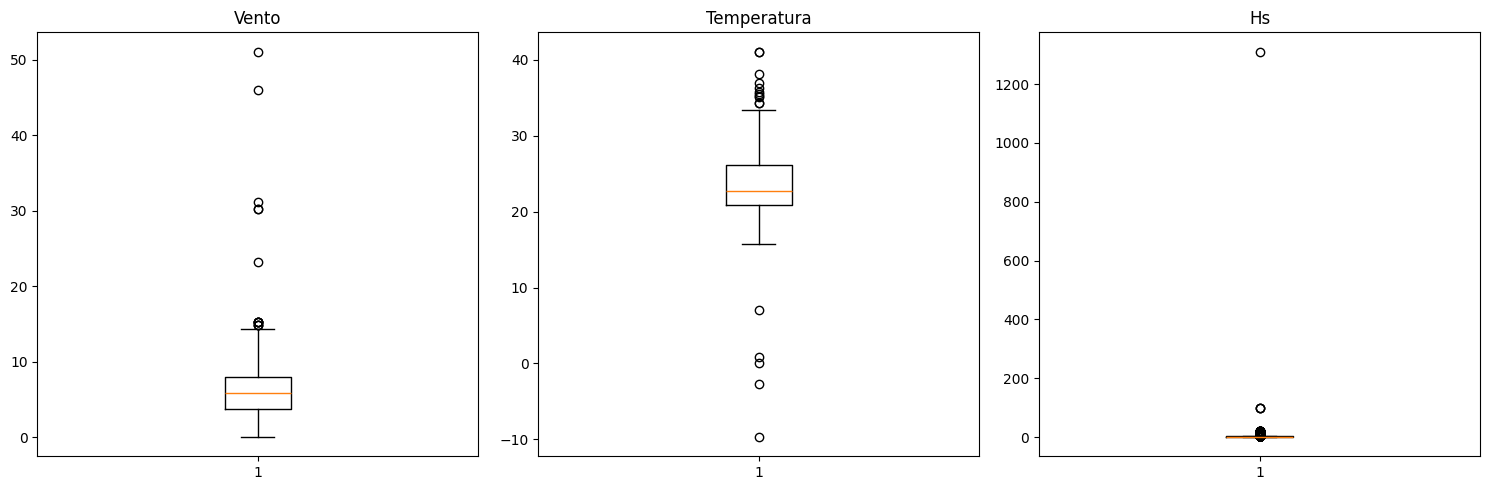

In [22]:
# ============================================================
# BLOCO 22 - BOXPLOTS
# ============================================================

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].boxplot(df_qc["vento"].dropna())
axs[0].set_title("Vento")

axs[1].boxplot(df_qc["temp_ar"].dropna())
axs[1].set_title("Temperatura")

axs[2].boxplot(df_qc["hs"].dropna())
axs[2].set_title("Hs")

plt.tight_layout()

plt.savefig(
    "qc5_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

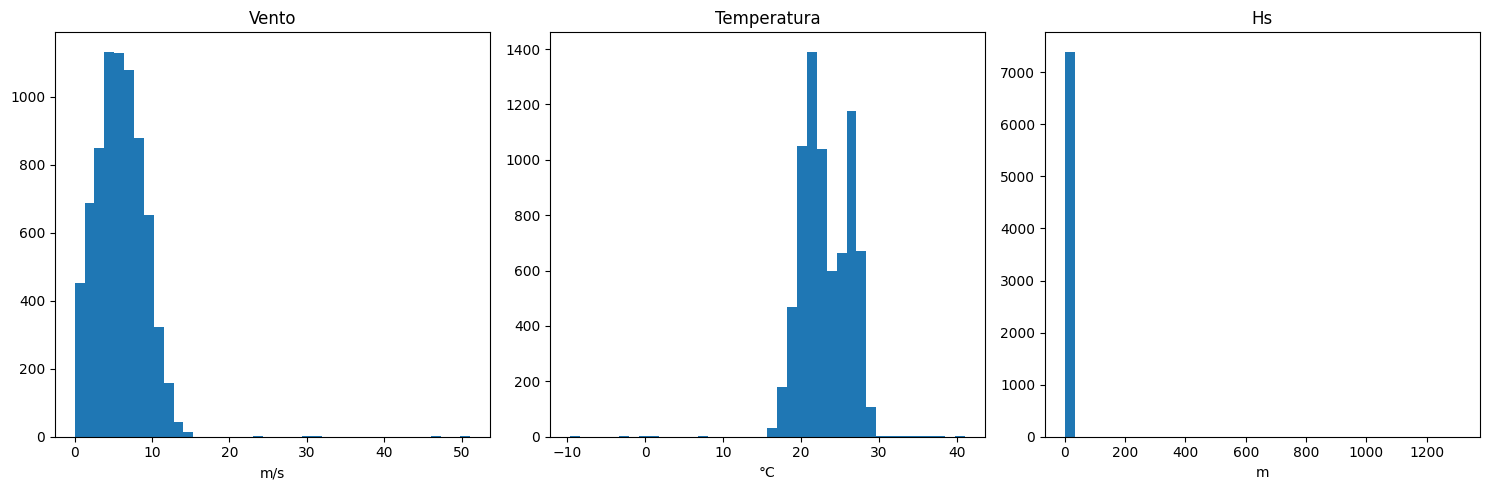

In [23]:
# ============================================================
# BLOCO 23 - HISTOGRAMAS DAS VARIÁVEIS
# ============================================================

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].hist(df_qc["vento"].dropna(), bins=40)
axs[0].set_title("Vento")
axs[0].set_xlabel("m/s")

axs[1].hist(df_qc["temp_ar"].dropna(), bins=40)
axs[1].set_title("Temperatura")
axs[1].set_xlabel("°C")

axs[2].hist(df_qc["hs"].dropna(), bins=40)
axs[2].set_title("Hs")
axs[2].set_xlabel("m")

plt.tight_layout()

plt.savefig(
    "qc5_histogramas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

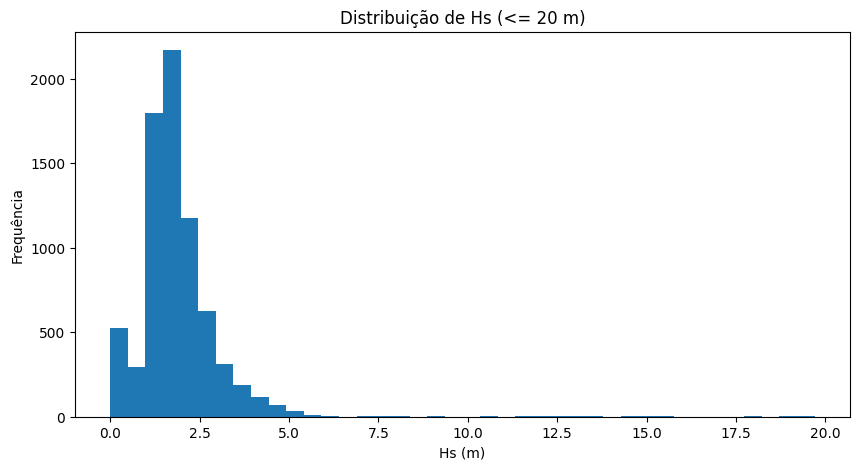

In [24]:
# ============================================================
# BLOCO 24 - HISTOGRAMA DE Hs SEM OUTLIERS EXTREMOS
# ============================================================

import matplotlib.pyplot as plt

hs_filtrado = df_qc["hs"].dropna()
hs_filtrado = hs_filtrado[hs_filtrado <= 20]

plt.figure(figsize=(10,5))

plt.hist(
    hs_filtrado,
    bins=40
)

plt.title("Distribuição de Hs (<= 20 m)")
plt.xlabel("Hs (m)")
plt.ylabel("Frequência")

plt.savefig(
    "qc6_histograma_hs_sem_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ============================================================
# BLOCO 25 - TABELA FINAL CONSOLIDADA DOS TESTES
# ============================================================

resumo_final = pd.DataFrame({
    "Variável": ["Vento", "Temperatura", "Hs"],

    "Registros válidos": [
        7401,
        7401,
        7401
    ],

    "Ausências": [
        3549,
        3549,
        3549
    ],

    "Fora da faixa": [
        2,
        2,
        14
    ],

    "Spikes": [
        34,
        215,
        156
    ],

    "Flat Line": [
        41,
        89,
        98
    ],

    "% sinalizado (sem ausências)": [
        1.013377,
        4.107553,
        3.567086
    ]
})

print("TABELA FINAL DO CONTROLE DE QUALIDADE")
display(resumo_final)

TABELA FINAL DO CONTROLE DE QUALIDADE


,Variável,Registros válidos,Ausências,Fora da faixa,Spikes,Flat Line,% sinalizado (sem ausências)
0,Vento,7401,3549,2,34,41,1.013377
1,Temperatura,7401,3549,2,215,89,4.107553
2,Hs,7401,3549,14,156,98,3.567086


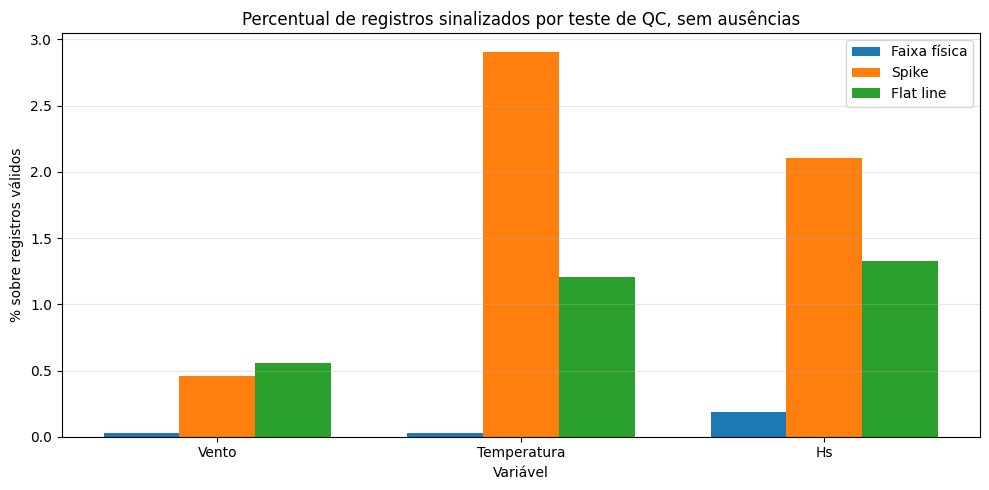

In [26]:
# ============================================================
# BLOCO 26 - GRÁFICO CONSOLIDADO SEM AUSÊNCIA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

variaveis = ["Vento", "Temperatura", "Hs"]

fora_faixa = [2/7401*100, 2/7401*100, 14/7401*100]
spikes = [34/7401*100, 215/7401*100, 156/7401*100]
flatline = [41/7401*100, 89/7401*100, 98/7401*100]

x = np.arange(len(variaveis))
largura = 0.25

plt.figure(figsize=(10, 5))

plt.bar(x - largura, fora_faixa, largura, label="Faixa física")
plt.bar(x, spikes, largura, label="Spike")
plt.bar(x + largura, flatline, largura, label="Flat line")

plt.xticks(x, variaveis)
plt.ylabel("% sobre registros válidos")
plt.xlabel("Variável")
plt.title("Percentual de registros sinalizados por teste de QC, sem ausências")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("fig_qc_sem_ausencia.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# ============================================================
# BLOCO 27 - QC5: OUTLIERS PELO MÉTODO IQR
# ============================================================

import pandas as pd

variaveis = ["vento", "temp_ar", "hs"]

resumo_qc5 = []

for var in variaveis:

    serie = df_qc[var].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    flag = (
        (df_qc[var] < limite_inferior)
        |
        (df_qc[var] > limite_superior)
    )

    df_qc[f"{var}_flag_iqr"] = flag

    n_outliers = flag.sum()

    resumo_qc5.append({
        "variavel": var,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lim_inf": limite_inferior,
        "lim_sup": limite_superior,
        "N_outliers": n_outliers,
        "%_outliers": 100*n_outliers/len(serie)
    })

resumo_qc5 = pd.DataFrame(resumo_qc5)

print("QC5 — OUTLIERS PELO MÉTODO IQR")
display(resumo_qc5)

QC5 — OUTLIERS PELO MÉTODO IQR


,variavel,Q1,Q3,IQR,lim_inf,lim_sup,N_outliers,%_outliers
0,vento,3.70,8.00,4.300000,-2.750000,14.450000,14,0.189164
1,temp_ar,20.90,26.10,5.200001,13.099998,33.900002,16,0.216187
2,hs,1.31,2.27,0.960000,-0.130000,3.710000,402,5.431698


In [28]:
# ============================================================
# BLOCO 28 - TABELA FINAL CONSOLIDADA COM QC5
# ============================================================

tabela_final_qc = pd.DataFrame({
    "Variável": ["Vento", "Temperatura", "Hs"],
    "Registros válidos": [7401, 7401, 7401],
    "Ausências": [3549, 3549, 3549],
    "Fora da faixa": [
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "vento", "N_fora_faixa"].values[0],
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "temp_ar", "N_fora_faixa"].values[0],
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "hs", "N_fora_faixa"].values[0],
    ],
    "Spikes": [
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "vento", "N_spikes"].values[0],
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "temp_ar", "N_spikes"].values[0],
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "hs", "N_spikes"].values[0],
    ],
    "Flat Line": [
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "vento", "N_flatline"].values[0],
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "temp_ar", "N_flatline"].values[0],
        resumo_consolidado.loc[resumo_consolidado["variavel"] == "hs", "N_flatline"].values[0],
    ],
    "Outliers IQR": [
        resumo_qc5.loc[resumo_qc5["variavel"] == "vento", "N_outliers"].values[0],
        resumo_qc5.loc[resumo_qc5["variavel"] == "temp_ar", "N_outliers"].values[0],
        resumo_qc5.loc[resumo_qc5["variavel"] == "hs", "N_outliers"].values[0],
    ],
    "% sinalizado sem ausências": [
        resumo_sem_ausencia.loc[resumo_sem_ausencia["variavel"] == "vento", "%_sinalizados_sobre_validos"].values[0],
        resumo_sem_ausencia.loc[resumo_sem_ausencia["variavel"] == "temp_ar", "%_sinalizados_sobre_validos"].values[0],
        resumo_sem_ausencia.loc[resumo_sem_ausencia["variavel"] == "hs", "%_sinalizados_sobre_validos"].values[0],
    ],
    "% outliers IQR": [
        resumo_qc5.loc[resumo_qc5["variavel"] == "vento", "%_outliers"].values[0],
        resumo_qc5.loc[resumo_qc5["variavel"] == "temp_ar", "%_outliers"].values[0],
        resumo_qc5.loc[resumo_qc5["variavel"] == "hs", "%_outliers"].values[0],
    ]
})

print("TABELA FINAL CONSOLIDADA — CONTROLE DE QUALIDADE")
display(tabela_final_qc)

TABELA FINAL CONSOLIDADA — CONTROLE DE QUALIDADE


,Variável,Registros válidos,Ausências,Fora da faixa,Spikes,Flat Line,Outliers IQR,% sinalizado sem ausências,% outliers IQR
0,Vento,7401,3549,2,34,41,14,1.013377,0.189164
1,Temperatura,7401,3549,2,215,89,16,4.107553,0.216187
2,Hs,7401,3549,14,156,98,402,3.567086,5.431698


In [29]:
# ============================================================
# BLOCO 29 - EXPORTAÇÃO DAS TABELAS DO TRABALHO II
# ============================================================

tabela_final_qc.to_csv("tabela_final_qc_trabalho2.csv", index=False)
resumo_consolidado.to_csv("resumo_consolidado_qc_trabalho2.csv", index=False)
resumo_sem_ausencia.to_csv("resumo_qc_sem_ausencia_trabalho2.csv", index=False)
resumo_qc5.to_csv("resumo_outliers_iqr_trabalho2.csv", index=False)

print("Arquivos exportados com sucesso:")
print("- tabela_final_qc_trabalho2.csv")
print("- resumo_consolidado_qc_trabalho2.csv")
print("- resumo_qc_sem_ausencia_trabalho2.csv")
print("- resumo_outliers_iqr_trabalho2.csv")

Arquivos exportados com sucesso:
- tabela_final_qc_trabalho2.csv
- resumo_consolidado_qc_trabalho2.csv
- resumo_qc_sem_ausencia_trabalho2.csv
- resumo_outliers_iqr_trabalho2.csv
